In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
# 1. Load the Dataset
# Ensure 'credit_risk_dataset.csv' is in the same directory
df = pd.read_csv('credit_risk_dataset.csv')

In [3]:
# 2. Data Cleaning
# Handling missing values using the modern Pandas approach

# Filling missing values for employment length
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Filling missing values for loan interest rate
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Removing outliers (as previously discussed)
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] < 60]

print("Data Cleaning and Outlier removal complete.")

Data Cleaning and Outlier removal complete.


Generating EDA Visualizations...


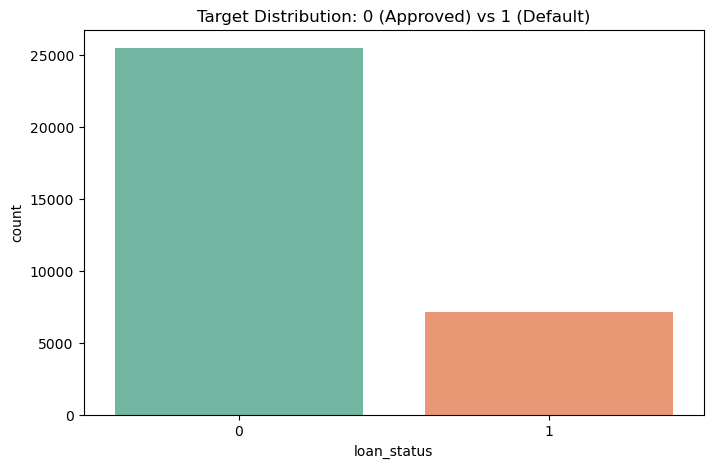

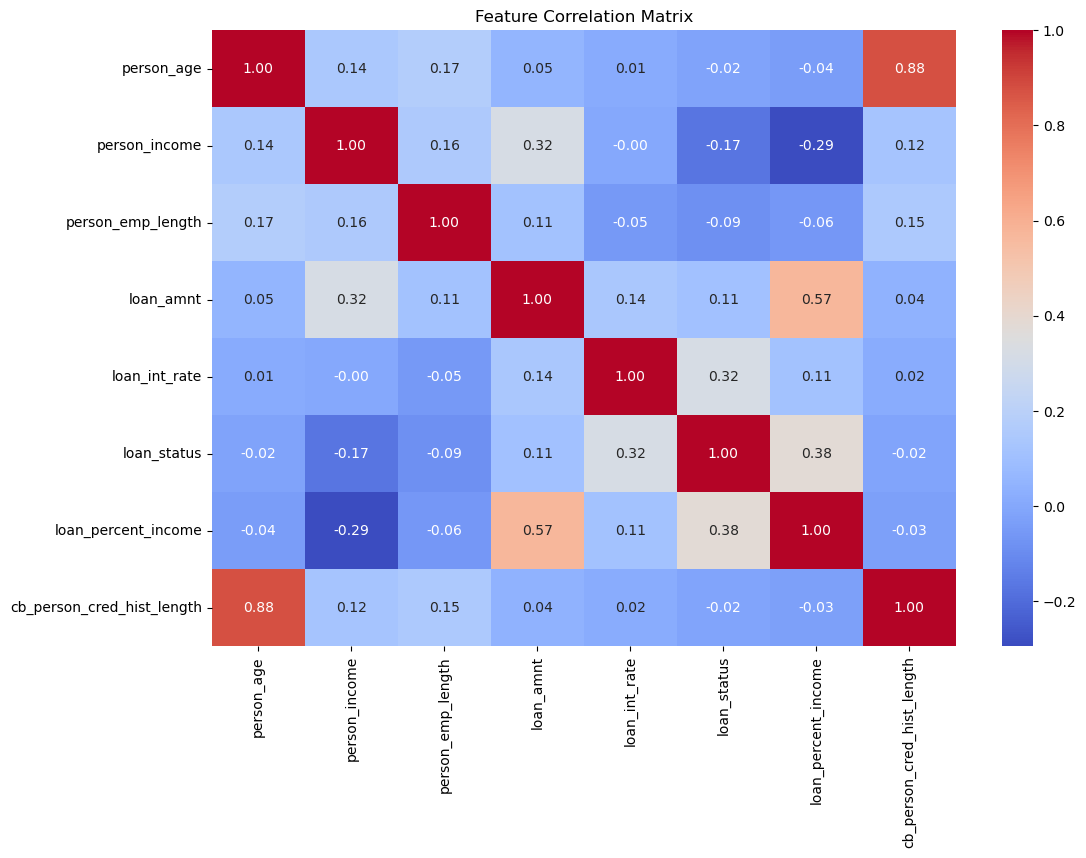

In [4]:
# 3. Exploratory Data Analysis (EDA) - Weekly Task (Week 7)
print("Generating EDA Visualizations...")

# Visualization 1: Target Distribution (Class Imbalance)
plt.figure(figsize=(8, 5))
# Added 'hue' and 'legend' to follow the new Seaborn standards
sns.countplot(x='loan_status', data=df, palette='Set2', hue='loan_status', legend=False)
plt.title('Target Distribution: 0 (Approved) vs 1 (Default)')
plt.savefig('loan_distribution.png')
plt.show()

# Visualization 2: Correlation Matrix
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.show()

In [5]:
# 4. Data Preprocessing for ML
# Encoding categorical variables (Convert text to numbers)
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Feature Selection
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [6]:
# 5. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Feature Scaling (Important for models like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete. Dataset is ready for Model Training.")

Preprocessing Complete. Dataset is ready for Model Training.


Training Random Forest Model...
Training XGBoost Model...
------------------------------
Random Forest Accuracy: 0.9338
XGBoost Accuracy: 0.9369
------------------------------

Detailed Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5099
           1       0.97      0.73      0.83      1416

    accuracy                           0.94      6515
   macro avg       0.95      0.86      0.90      6515
weighted avg       0.94      0.94      0.93      6515



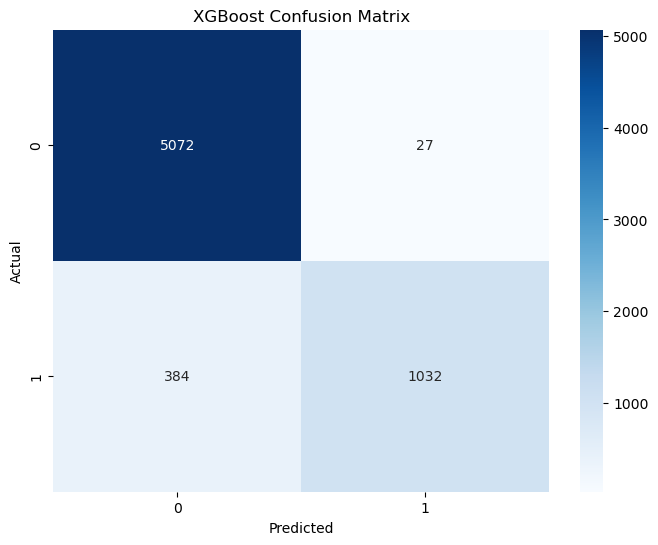

In [7]:
# 6. Methodology

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Building the Random Forest Model
print("Training Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Random Forest Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# 2. Building the XGBoost Model
print("Training XGBoost Model...")
# We use scale_pos_weight to handle the class imbalance we found in Week 7
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# XGBoost Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

# 3. Comparing Results
print("-" * 30)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print("-" * 30)

# 4. Detailed Performance Report for XGBoost (Our Primary Model)
print("\nDetailed Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

# 5. Visualizing Confusion Matrix for the Paper
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

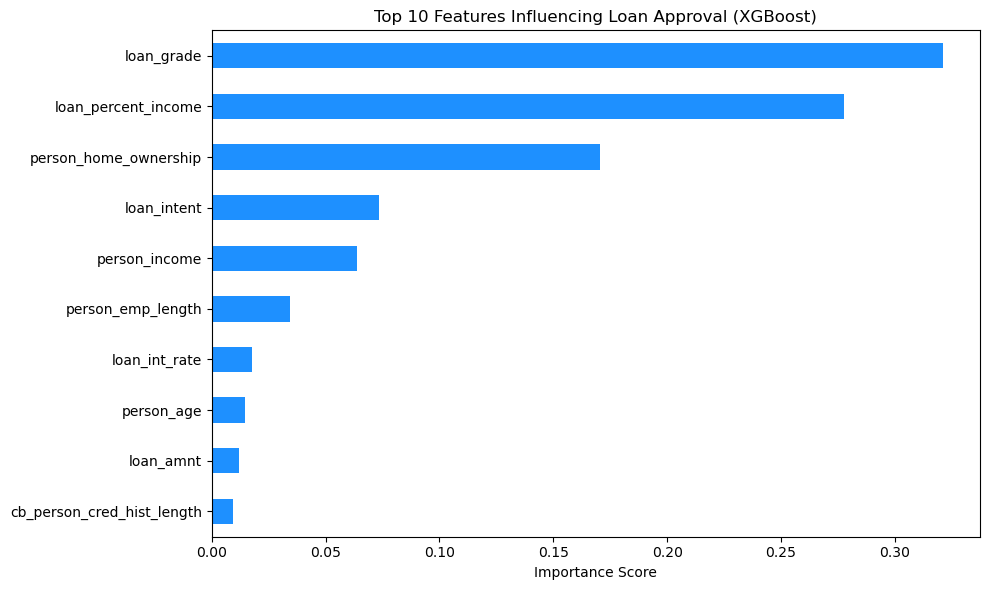


--- Model Comparison Table ---
      Metric  Random Forest  XGBoost
0   Accuracy         0.9338   0.9369
1  Precision         0.9659   0.9745
2     Recall         0.7210   0.7288
3   F1-Score         0.8257   0.8339


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score, precision_score

# 1. Feature Importance Plot
plt.figure(figsize=(10, 6))
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
xgb_importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='dodgerblue')
plt.title('Top 10 Features Influencing Loan Approval (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# 2. Model Comparison Table
results_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [
        rf_accuracy, 
        precision_score(y_test, y_pred_rf), 
        recall_score(y_test, y_pred_rf), 
        f1_score(y_test, y_pred_rf)
    ],
    'XGBoost': [
        xgb_accuracy, 
        precision_score(y_test, y_pred_xgb), 
        recall_score(y_test, y_pred_xgb), 
        f1_score(y_test, y_pred_xgb)
    ]
}

df_comparison = pd.DataFrame(results_data)
print("\n--- Model Comparison Table ---")
print(df_comparison.round(4))

Calculated weight ratio: 3.58
Balanced Accuracy: 0.9200


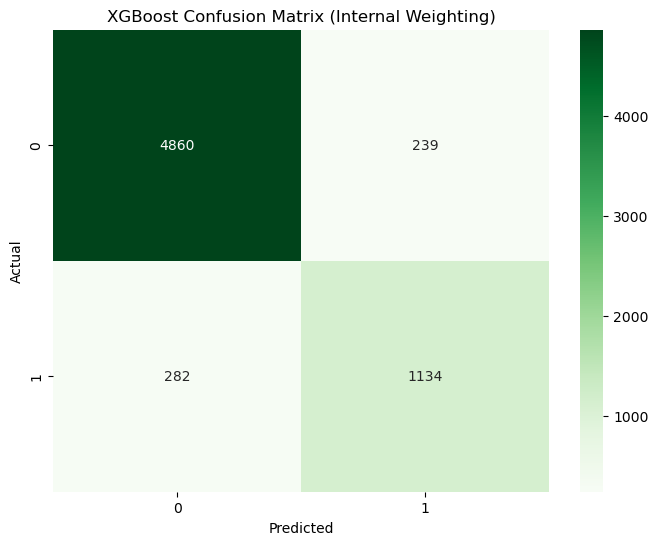

In [9]:
# We use scale_pos_weight to handle imbalance
# Formula: number of negative samples / number of positive samples
ratio = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Calculated weight ratio: {ratio:.2f}")

# Train XGBoost with the weight ratio
xgb_balanced = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42,
    scale_pos_weight=ratio # This balances the classes internally
)
xgb_balanced.fit(X_train_scaled, y_train)

# Predictions
y_pred_balanced = xgb_balanced.predict(X_test_scaled)
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

# Save the new Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_balanced), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix (Internal Weighting)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix_balanced.png')
plt.show()

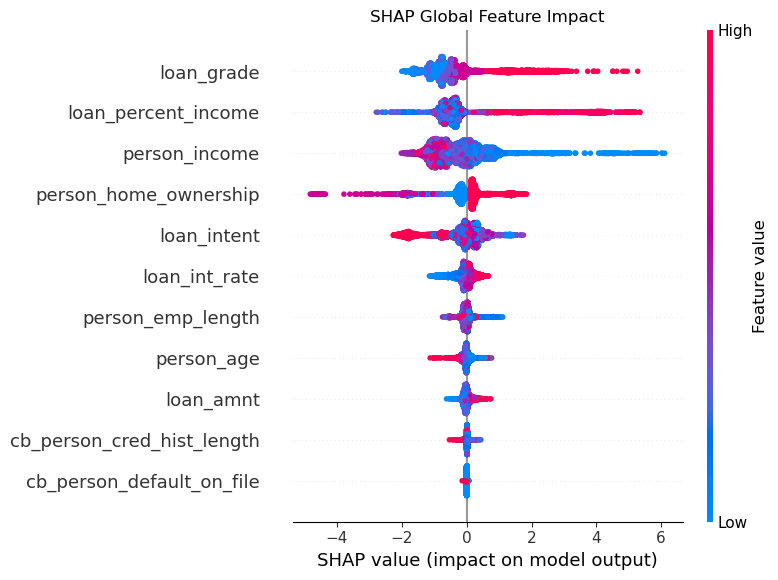

In [10]:
# XAI

import shap
import matplotlib.pyplot as plt

# Create the SHAP Explainer
explainer = shap.TreeExplainer(xgb_balanced)
shap_values = explainer.shap_values(X_test_scaled)

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.title("SHAP Global Feature Impact")
plt.tight_layout()
plt.savefig('shap_summary.png')
plt.show()

In [11]:
# Fairness analysis by age
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
y_test_reset = y_test.reset_index(drop=True)

# Split by mean age (as a proxy for younger vs older)
mask = X_test_df['person_age'] < X_test_df['person_age'].mean()
acc_young = accuracy_score(y_test_reset[mask], y_pred_balanced[mask])
acc_older = accuracy_score(y_test_reset[~mask], y_pred_balanced[~mask])

print(f"Accuracy for Younger Group: {acc_young:.4f}")
print(f"Accuracy for Older Group: {acc_older:.4f}")
print(f"Fairness Gap: {abs(acc_young - acc_older):.4f}")

Accuracy for Younger Group: 0.9201
Accuracy for Older Group: 0.9200
Fairness Gap: 0.0001
